In [22]:
from __future__ import annotations
import os
from dataclasses import dataclass
from typing import Literal, Optional, Tuple, Dict
import numpy as np
import pandas as pd


@dataclass
class BuildConfig:
    train_events_path: str = "../data/processed/chicago_clean_2015_2024.parquet"
    test_events_path: str = "../data/processed/chicago_clean_2025.parquet"

    out_train_table: str = "../data/processed/train_table_train_2015_2024.parquet"
    out_test_table: str = "../data/processed/train_table_test_2025.parquet"

    out_grid_meta: str = "../data/processed/grid_metadata.parquet"

    date_col: str = "date"
    lat_col: str = "latitude"
    lon_col: str = "longitude"

    time_freq: Literal["W", "D"] = "W"
    task: Literal["classification", "regression"] = "classification"
    grid_size_m: float = 1000.0
    bbox: Optional[Tuple[float, float, float, float]] = None
    complete_all_time_bins: bool = True
    min_cell_total_count: int = 10
    label_is_next_positive: bool = True
    preview_n: int = 10
    preview_seed: int = 42
    train_table = pd.read_parquet("../data/processed/train_table_train_2015_2024.parquet")

In [23]:
# -------------------------
# Module 1) load_events
# -------------------------
def load_events(path: str, cfg: BuildConfig) -> pd.DataFrame:
    df = pd.read_parquet(path)

    required = [cfg.date_col, cfg.lat_col, cfg.lon_col]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(
            f"Missing required columns {missing} in {path}. "
            f"Available columns: {df.columns.tolist()}"
        )

    df = df.copy()
    df[cfg.date_col] = pd.to_datetime(df[cfg.date_col], errors="coerce")
    df = df.dropna(subset=[cfg.date_col]).copy()

    df[cfg.lat_col] = pd.to_numeric(df[cfg.lat_col], errors="coerce")
    df[cfg.lon_col] = pd.to_numeric(df[cfg.lon_col], errors="coerce")
    df = df.dropna(subset=[cfg.lat_col, cfg.lon_col]).copy()

    return df

In [24]:
# -------------------------
# Module 2) make_time_bin
# -------------------------
def make_time_bin(df: pd.DataFrame, date_col: str, freq: str) -> pd.DataFrame:
    df = df.copy()

    if freq == "D":
        df["time_bin"] = df[date_col].dt.floor("D")
    elif freq == "W":
        df["time_bin"] = df[date_col].dt.to_period("W").dt.start_time
    else:
        raise ValueError(f"Unsupported freq: {freq}. Use 'W' or 'D'.")

    return df


# -------------------------
# Grid utils
# -------------------------
def infer_bbox(df: pd.DataFrame, lat_col: str, lon_col: str) -> Tuple[float, float, float, float]:
    min_lat = float(df[lat_col].min())
    max_lat = float(df[lat_col].max())
    min_lon = float(df[lon_col].min())
    max_lon = float(df[lon_col].max())

    pad_lat = (max_lat - min_lat) * 0.001 if max_lat > min_lat else 0.0001
    pad_lon = (max_lon - min_lon) * 0.001 if max_lon > min_lon else 0.0001
    return (min_lat - pad_lat, max_lat + pad_lat, min_lon - pad_lon, max_lon + pad_lon)


def meters_per_degree(lat0: float) -> Tuple[float, float]:
    m_per_deg_lat = 111_320.0
    m_per_deg_lon = 111_320.0 * float(np.cos(np.deg2rad(lat0)))
    m_per_deg_lon = max(m_per_deg_lon, 1e-6)
    return m_per_deg_lat, m_per_deg_lon


def make_grid_id(df: pd.DataFrame, cfg: BuildConfig) -> Tuple[pd.DataFrame, Dict[str, float]]:
    out = df.copy()

    bbox = infer_bbox(out, cfg.lat_col, cfg.lon_col) if cfg.bbox is None else cfg.bbox
    min_lat, max_lat, min_lon, max_lon = bbox

    lat0 = (min_lat + max_lat) / 2.0
    m_per_deg_lat, m_per_deg_lon = meters_per_degree(lat0)

    dy_m = (out[cfg.lat_col] - min_lat) * m_per_deg_lat
    dx_m = (out[cfg.lon_col] - min_lon) * m_per_deg_lon

    grid_row = np.floor(dy_m / cfg.grid_size_m).astype(int)
    grid_col = np.floor(dx_m / cfg.grid_size_m).astype(int)

    valid = (grid_row >= 0) & (grid_col >= 0)
    out = out.loc[valid].copy()
    grid_row = grid_row[valid]
    grid_col = grid_col[valid]

    out["grid_row"] = grid_row
    out["grid_col"] = grid_col
    out["cell_id"] = ("r" + out["grid_row"].astype(str) + "_c" + out["grid_col"].astype(str))

    grid_meta = {
        "min_lat": float(min_lat),
        "max_lat": float(max_lat),
        "min_lon": float(min_lon),
        "max_lon": float(max_lon),
        "lat0": float(lat0),
        "m_per_deg_lat": float(m_per_deg_lat),
        "m_per_deg_lon": float(m_per_deg_lon),
        "grid_size_m": float(cfg.grid_size_m),
    }
    return out, grid_meta


def build_grid_metadata(events_with_grid: pd.DataFrame, cfg: BuildConfig, grid_meta: Dict[str, float]) -> pd.DataFrame:
    cells = events_with_grid[["cell_id", "grid_row", "grid_col"]].drop_duplicates().copy()

    min_lat = grid_meta["min_lat"]
    min_lon = grid_meta["min_lon"]
    m_per_deg_lat = grid_meta["m_per_deg_lat"]
    m_per_deg_lon = grid_meta["m_per_deg_lon"]
    size_m = grid_meta["grid_size_m"]

    center_lat = min_lat + ((cells["grid_row"].astype(float) + 0.5) * size_m) / m_per_deg_lat
    center_lon = min_lon + ((cells["grid_col"].astype(float) + 0.5) * size_m) / m_per_deg_lon

    lat_min = min_lat + (cells["grid_row"].astype(float) * size_m) / m_per_deg_lat
    lat_max = min_lat + ((cells["grid_row"].astype(float) + 1.0) * size_m) / m_per_deg_lat
    lon_min = min_lon + (cells["grid_col"].astype(float) * size_m) / m_per_deg_lon
    lon_max = min_lon + ((cells["grid_col"].astype(float) + 1.0) * size_m) / m_per_deg_lon

    meta = cells.copy()
    meta["center_lat"] = center_lat.astype(float)
    meta["center_lon"] = center_lon.astype(float)
    meta["cell_lat_min"] = lat_min.astype(float)
    meta["cell_lat_max"] = lat_max.astype(float)
    meta["cell_lon_min"] = lon_min.astype(float)
    meta["cell_lon_max"] = lon_max.astype(float)

    meta["grid_size_m"] = float(cfg.grid_size_m)
    meta["grid_min_lat"] = float(grid_meta["min_lat"])
    meta["grid_max_lat"] = float(grid_meta["max_lat"])
    meta["grid_min_lon"] = float(grid_meta["min_lon"])
    meta["grid_max_lon"] = float(grid_meta["max_lon"])

    return meta.sort_values(["grid_row", "grid_col"]).reset_index(drop=True)

In [25]:
# -------------------------
# Module 3) aggregate_panel_city (name unchanged)
# -------------------------
def aggregate_panel_city(df: pd.DataFrame) -> pd.DataFrame:
    if "cell_id" not in df.columns:
        panel = (
            df.groupby(["time_bin"], as_index=False)
              .size()
              .rename(columns={"size": "crime_count"})
        )
        panel["crime_count"] = panel["crime_count"].astype(int)
        panel["cell_id"] = "city"
        panel = panel[["cell_id", "time_bin", "crime_count"]]
        return panel

    panel = (
        df.groupby(["cell_id", "time_bin"], as_index=False)
          .size()
          .rename(columns={"size": "crime_count"})
    )
    panel["crime_count"] = panel["crime_count"].astype(int)
    panel = panel[["cell_id", "time_bin", "crime_count"]]
    return panel

In [26]:
# -------------------------
# Module 4) complete_panel
# -------------------------
def complete_panel(panel: pd.DataFrame, freq: str) -> pd.DataFrame:
    panel = panel.copy()
    cells = panel["cell_id"].unique()
    tmin, tmax = panel["time_bin"].min(), panel["time_bin"].max()

    if freq == "D":
        full_time = pd.date_range(tmin, tmax, freq="D")
    elif freq == "W":
        full_time = pd.date_range(tmin, tmax, freq="7D")
    else:
        raise ValueError(f"Unsupported freq: {freq}. Use 'W' or 'D'.")

    full_index = pd.MultiIndex.from_product([cells, full_time], names=["cell_id", "time_bin"])
    out = (
        panel.set_index(["cell_id", "time_bin"])
             .reindex(full_index)
             .fillna(0)
             .reset_index()
    )
    out["crime_count"] = out["crime_count"].astype(int)
    return out


def filter_sparse_cells(panel: pd.DataFrame, min_total: int) -> pd.DataFrame:
    if min_total <= 0:
        return panel
    sums = panel.groupby("cell_id")["crime_count"].sum()
    keep_cells = sums[sums >= min_total].index
    return panel[panel["cell_id"].isin(keep_cells)].copy()



In [27]:
# -------------------------
# Module 5) make_label
# -------------------------
def make_label(panel: pd.DataFrame, task: str, cfg: BuildConfig) -> pd.DataFrame:
    out = panel.sort_values(["cell_id", "time_bin"]).copy()
    g = out.groupby("cell_id", group_keys=False)

    out["y_next_count"] = g["crime_count"].shift(-1)
    out = out.dropna(subset=["y_next_count"]).copy()

    if task == "classification":
        if cfg.label_is_next_positive:
            out["y"] = (out["y_next_count"] > 0).astype(int)
        else:
            out["hist_mean"] = (
                g["crime_count"]
                .shift(1)
                .expanding()
                .mean()
                .reset_index(level=0, drop=True)
            )
            out = out.dropna(subset=["hist_mean"]).copy()
            out["y"] = (out["y_next_count"] > out["hist_mean"]).astype(int)
    else:
        out["y"] = out["y_next_count"].astype(int)

    return out



In [28]:
# -------------------------
# Module 6) make_features
# -------------------------
def make_features(panel_with_y: pd.DataFrame) -> pd.DataFrame:
    out = panel_with_y.sort_values(["cell_id", "time_bin"]).copy()
    g = out.groupby("cell_id", group_keys=False)

    dt = pd.to_datetime(out["time_bin"])
    out["year"] = dt.dt.year
    out["month"] = dt.dt.month
    out["weekofyear"] = dt.dt.isocalendar().week.astype(int)
    out["dayofweek"] = dt.dt.dayofweek

    out["lag_1"] = g["crime_count"].shift(1)
    out["lag_2"] = g["crime_count"].shift(2)
    out["lag_4"] = g["crime_count"].shift(4)

    base = g["crime_count"].shift(1)
    out["roll_mean_4"] = base.rolling(4).mean()
    out["roll_sum_4"] = base.rolling(4).sum()
    out["roll_mean_8"] = base.rolling(8).mean()
    out["roll_sum_8"] = base.rolling(8).sum()
    out["roll_std_8"] = base.rolling(8).std()

    feat_cols = [
        "lag_1", "lag_2", "lag_4",
        "roll_mean_4", "roll_sum_4",
        "roll_mean_8", "roll_sum_8", "roll_std_8"
    ]
    out[feat_cols] = out[feat_cols].fillna(0.0)
    return out

In [29]:
# -------------------------
# finalize_table
# -------------------------
def finalize_table(df: pd.DataFrame) -> pd.DataFrame:
    keep_cols = [
        "cell_id", "time_bin", "y",
        "year", "month", "weekofyear", "dayofweek",
        "lag_1", "lag_2", "lag_4",
        "roll_mean_4", "roll_sum_4",
        "roll_mean_8", "roll_sum_8", "roll_std_8"
    ]
    out = df[keep_cols].copy()

    feature_cols = [c for c in out.columns if c not in ["cell_id", "time_bin", "y"]]
    for c in feature_cols:
        out[c] = (
            pd.to_numeric(out[c], errors="coerce")
              .replace([np.inf, -np.inf], np.nan)
              .fillna(0.0)
        )

    out["y"] = pd.to_numeric(out["y"], errors="coerce").fillna(0).astype(int)
    return out


def save_parquet(df: pd.DataFrame, path: str) -> None:
    os.makedirs(os.path.dirname(path), exist_ok=True)
    df.to_parquet(path, index=False)



def report_preview(train_table: pd.DataFrame, cfg: BuildConfig) -> None:
    cols_show = [
        "cell_id", "time_bin", "y",
        "lag_1", "lag_2", "lag_4",
        "roll_sum_4", "roll_sum_8", "roll_std_8",
        "month", "weekofyear", "dayofweek"
    ]
    cols_show = [c for c in cols_show if c in train_table.columns]

    print("\n[Preview A] Informative random samples (lag/rolling > 0):")
    informative = train_table[(train_table["lag_1"] > 0) | (train_table["roll_sum_4"] > 0)].copy()
    if len(informative) >= cfg.preview_n:
        sample_a = informative.sample(cfg.preview_n, random_state=cfg.preview_seed)
    else:
        sample_a = train_table.sample(min(cfg.preview_n, len(train_table)), random_state=cfg.preview_seed)
    print(sample_a[cols_show].to_string(index=False))

    print("\n[Preview B] Positive vs Negative samples (y=1 and y=0):")
    pos = train_table[train_table["y"] == 1]
    neg = train_table[train_table["y"] == 0]
    if len(pos) > 0:
        print("\n  - y=1 samples:")
        print(pos.sample(min(5, len(pos)), random_state=cfg.preview_seed)[cols_show].to_string(index=False))
    if len(neg) > 0:
        print("\n  - y=0 samples:")
        print(neg.sample(min(5, len(neg)), random_state=cfg.preview_seed)[cols_show].to_string(index=False))

    print("\n[Preview C] Representative cell time series snippet (top activity cell):")
 
    cell = (
        train_table.groupby("cell_id")["roll_sum_8"]
        .mean()
        .sort_values(ascending=False)
        .index[0]
    )
    ts = train_table[train_table["cell_id"] == cell].sort_values("time_bin").head(15)
    print(f"  representative cell_id = {cell}")
    print(ts[cols_show].to_string(index=False))

    print("\n[Summary] Key feature distribution (describe + nonzero ratio):")
    key_cols = ["y", "lag_1", "roll_sum_4", "roll_sum_8"]
    key_cols = [c for c in key_cols if c in train_table.columns]
    desc = train_table[key_cols].describe().T
    desc["nonzero_ratio"] = (train_table[key_cols] > 0).mean().values
    print(desc.to_string())


# -------------------------
# pipeline
# -------------------------
def build_one(events_path: str, cfg: BuildConfig, events_df: pd.DataFrame | None = None) -> pd.DataFrame:
    if events_df is None:
        events = load_events(events_path, cfg)
    else:
        events = events_df.copy()

    events = make_time_bin(events, cfg.date_col, cfg.time_freq)
    events, _grid_meta = make_grid_id(events, cfg)
    panel = aggregate_panel_city(events)

    if cfg.complete_all_time_bins:
        panel = complete_panel(panel, cfg.time_freq)

    panel = make_label(panel, cfg.task, cfg)
    panel = make_features(panel)
    table = finalize_table(panel)
    return table

def main():
    cfg = BuildConfig()

    train_events = load_events(cfg.train_events_path, cfg)
    test_events = load_events(cfg.test_events_path, cfg)
    all_events = pd.concat([train_events, test_events], ignore_index=True)


    all_events = make_time_bin(all_events, cfg.date_col, cfg.time_freq)
    all_events_with_grid, grid_meta = make_grid_id(all_events, cfg)


    grid_metadata = build_grid_metadata(all_events_with_grid, cfg, grid_meta)
    save_parquet(grid_metadata, cfg.out_grid_meta)

    all_table = build_one(cfg.train_events_path, cfg, events_df=all_events)

    tb = pd.to_datetime(all_table["time_bin"])
    train_table = all_table[tb.dt.year <= 2024].copy()
    test_table = all_table[tb.dt.year == 2025].copy()

    if cfg.min_cell_total_count > 0:
        train_events_with_grid = all_events_with_grid[pd.to_datetime(all_events_with_grid["time_bin"]).dt.year <= 2024].copy()
        train_panel = aggregate_panel_city(train_events_with_grid)
        if cfg.complete_all_time_bins:
            train_panel = complete_panel(train_panel, cfg.time_freq)

        train_panel = filter_sparse_cells(train_panel, cfg.min_cell_total_count)
        keep_cells = train_panel["cell_id"].unique()

        train_table = train_table[train_table["cell_id"].isin(keep_cells)].copy()
        test_table = test_table[test_table["cell_id"].isin(keep_cells)].copy()

    save_parquet(train_table, cfg.out_train_table)
    save_parquet(test_table, cfg.out_test_table)

    print("Grid metadata:", grid_metadata.shape, " unique cells:", grid_metadata["cell_id"].nunique())
    print("Train table:", train_table.shape, " y mean:", float(train_table["y"].mean()))
    print("Test table :", test_table.shape, " y mean:", float(test_table["y"].mean()))


    report_preview(train_table, cfg)


if __name__ == "__main__":
    main()

Grid metadata: (666, 14)  unique cells: 666
Train table: (325829, 15)  y mean: 0.5877101178839207
Test table : (31773, 15)  y mean: 0.570264060680452

[Preview A] Informative random samples (lag/rolling > 0):
cell_id   time_bin  y  lag_1  lag_2  lag_4  roll_sum_4  roll_sum_8  roll_std_8  month  weekofyear  dayofweek
 r33_c8 2018-05-07  0    0.0    0.0    1.0         1.0         1.0    0.353553      5          19          0
r31_c15 2018-11-19  1    1.0    1.0    2.0         7.0        16.0    0.925820     11          47          0
r39_c22 2017-09-04  1    2.0    2.0    5.0        13.0        26.0    1.164965      9          36          0
r11_c26 2017-09-25  1    5.0    2.0    3.0        12.0        26.0    1.035098      9          39          0
r39_c16 2020-02-24  0    0.0    0.0    0.0         1.0         1.0    0.353553      2           9          0
r16_c27 2022-12-12  0    1.0    2.0    0.0         3.0         6.0    0.886405     12          50          0
r35_c16 2017-03-06  1    2.0

In [ ]:
train_table = pd.read_parquet("../data/processed/train_table_train_2015_2024.parquet")
print(train_table[["y","lag_1","roll_sum_4","roll_sum_8"]].describe())
print("nonzero lag_1 rows:", (train_table["lag_1"]>0).sum())
print("nonzero roll_sum_4 rows:", (train_table["roll_sum_4"]>0).sum())
print("y mean:", train_table["y"].mean())

                   y          lag_1     roll_sum_4     roll_sum_8
count  325829.000000  325829.000000  325829.000000  325829.000000
mean        0.587710       1.709415       6.806374      13.513315
std         0.492248       3.288128      11.781094      22.998458
min         0.000000       0.000000       0.000000       0.000000
25%         0.000000       0.000000       1.000000       3.000000
50%         1.000000       1.000000       4.000000       8.000000
75%         1.000000       2.000000       9.000000      17.000000
max         1.000000     300.000000     345.000000     590.000000
nonzero lag_1 rows: 191065
nonzero roll_sum_4 rows: 270039
y mean: 0.5877101178839207


In [31]:
import pandas as pd

cols = ["lag_1", "lag_2", "lag_4", "roll_sum_4", "roll_sum_8", "roll_mean_4", "roll_mean_8", "roll_std_8"]
cols = [c for c in cols if c in train_table.columns]

def agg_block(df, name):
    out = df[cols].agg(["mean", "median", "std"])
    out.index = [f"{name}_mean", f"{name}_median", f"{name}_std"]
    return out

pos = train_table[train_table["y"] == 1]
neg = train_table[train_table["y"] == 0]

summary = pd.concat([agg_block(pos, "y1"), agg_block(neg, "y0")])
delta = (summary.loc["y1_mean"] - summary.loc["y0_mean"]).to_frame("mean_diff(y1-y0)").T

display(summary)
display(delta)

,lag_1,lag_2,lag_4,roll_sum_4,roll_sum_8,roll_mean_4,roll_mean_8,roll_std_8
y1_mean,2.492566,2.486571,2.473464,9.914749,19.669335,2.478687,2.458667,1.448059
y1_median,2.000000,2.000000,2.000000,7.000000,14.000000,1.750000,1.750000,1.281740
y1_std,4.020378,4.019584,4.016371,14.358580,28.023276,3.589645,3.502909,1.514779
y0_mean,0.593050,0.594807,0.597539,2.375454,4.738045,0.593864,0.592256,0.623966
y0_median,0.000000,0.000000,0.000000,1.000000,3.000000,0.250000,0.375000,0.517549
y0_std,1.030834,1.038760,1.052173,3.057397,5.696350,0.764349,0.712044,0.531979


,lag_1,lag_2,lag_4,roll_sum_4,roll_sum_8,roll_mean_4,roll_mean_8,roll_std_8
mean_diff(y1-y0),1.899516,1.891764,1.875925,7.539295,14.93129,1.884824,1.866411,0.824093


In [17]:
cell = (
    train_table.groupby("cell_id")["roll_sum_8"]
    .mean()
    .sort_values(ascending=False)
    .index[0]
)

ts = train_table[train_table["cell_id"] == cell].sort_values("time_bin").tail(20)

display(ts[[
    "cell_id","time_bin","y",
    "lag_1","roll_sum_4","roll_sum_8",
    "month","weekofyear","dayofweek"
]])

,cell_id,time_bin,y,lag_1,roll_sum_4,roll_sum_8,month,weekofyear,dayofweek
145897,r26_c25,2024-08-19,1,25.0,152.0,297.0,8,34,0
145898,r26_c25,2024-08-26,1,37.0,142.0,300.0,8,35,0
145899,r26_c25,2024-09-02,1,38.0,139.0,318.0,9,36,0
145900,r26_c25,2024-09-09,1,35.0,135.0,299.0,9,37,0
145901,r26_c25,2024-09-16,1,35.0,145.0,297.0,9,38,0
145902,r26_c25,2024-09-23,1,37.0,145.0,287.0,9,39,0
145903,r26_c25,2024-09-30,1,40.0,147.0,286.0,9,40,0
145904,r26_c25,2024-10-07,1,38.0,150.0,285.0,10,41,0
145905,r26_c25,2024-10-14,1,47.0,162.0,307.0,10,42,0
145906,r26_c25,2024-10-21,1,34.0,159.0,304.0,10,43,0


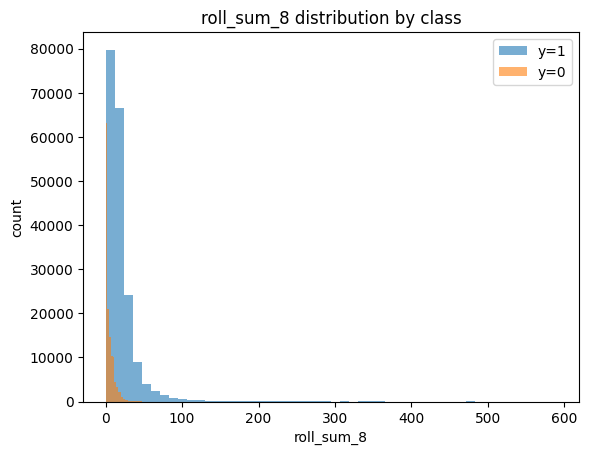

In [18]:
import matplotlib.pyplot as plt

pos = train_table[train_table["y"]==1]["roll_sum_8"]
neg = train_table[train_table["y"]==0]["roll_sum_8"]

plt.figure()
plt.hist(pos, bins=50, alpha=0.6, label="y=1")
plt.hist(neg, bins=50, alpha=0.6, label="y=0")
plt.legend()
plt.title("roll_sum_8 distribution by class")
plt.xlabel("roll_sum_8")
plt.ylabel("count")
plt.show()